<a href="https://colab.research.google.com/github/uttradewangan222-svg/CTRL-alt-Elites/blob/main/Digit_Recognizer%20Using%20ANN%20(AI%20project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Nueral Network from scratch  - MNIST Digit Recognizer

In [1]:
#@title Installing the important libraries
!pip install torch torchvision matplotlib numpy

In [ ]:
#@title Importing the neccessary libraries
import torch # The core AI engine. It is the main deep learning library.
'''-> Tensor (Multidimensional arrays)
   -> Mathematical operations
   -> Nueral Network computations
   -> GPU acceleration
   -> Automatic differentiation (Backpropagation)
      torch = AI brain + Mathematics engine    '''
import torchvision
'''Torchvision is a support library for computer vision tasks .
   provides:
            ready datasets
            image processing tools
            pretrained models
    Example Dataset available
    MNIST
    CIFAR - 10
    imageNet
            torchvision = image dataset + computer vision helper'''
import torchvision.transforms as transforms
'''Inside torchvision there is a module called transform.
    It is used to modigy images before feeding them to the nueral network.
    Nueral network cannot process raw images.'''
import matplotlib.pyplot as plt #use to show images, training graphs, make prediction
import numpy as np # used for numerical operations

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

'''Pytorch  = brain
   Torchvision = dataset manager
   Matplotlib = visualization
   numpy = Mathematical operations'''

True
Tesla T4


'Pytorch  = brain\n   Torchvision = dataset manager\n   Matplotlib = visualization\n   numpy = Mathematical operations'

In [ ]:
#@title Convert image into Tensors
# Transform image into tensor format so Nueral Network can process them
#Each image pixel will be converted into number between 0- Black , 1 - White
#SO the AI can process the image mathematically.
transform  = transforms.ToTensor()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#@title Load the Datasets
train_dataset = torchvision.datasets.MNIST( #Download and load the training datasets
    root = 'Mydrive./data', # FOlder where the dataset will be stored
    train = True, # Specifies this is the training data
    transform = transform,# Apply Tensor conversion
    download = True # Dowload datset if not already available
)
'''IT downloads 60000 training images of hardwritting digits
   Each image 28*28 pixel , Grayscale labelled from 0-9'''

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]


'IT downloads 60000 training images of hardwritting digits\n   Each image 28*28 pixel , Grayscale labelled from 0-9'

In [ ]:
#@title Load Test Datasets
test_datasets = torchvision.datasets.MNIST(
    root = 'Mydrive./data',
    train = False, # This the test dataset
    transform = transform,
    download = True
)
'''THis dataset contains 10000 test images. used to check model accuracy'''

'THis dataset contains 10000 test images. used to check model accuracy'

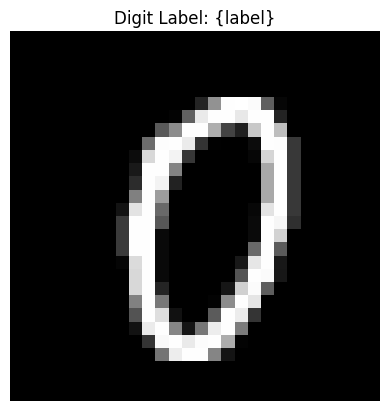

'What the code does\n   Take the first handwritten digit\n   display the image\n   showss the correct label'

In [ ]:
#@title Visualisation a digit
image, label = train_dataset[1000] # get the first image and lable from the dataset
plt.imshow(image.squeeze(), cmap = 'gray') # Display The image
plt.title("Digit Label: {label}") # Show the label as title
plt.axis('off') # Remove axis numbers
plt.show()

'''What the code does
   Take the first handwritten digit
   display the image
   showss the correct label'''

In [ ]:
#@title Building Nueral Network
import torch.nn as nn # nn = Nueral Network module to build nuerons of AI

#Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#Define Nueral Network class
class NeuralNetwork(nn.Module):  #nn.Module = Blueprint for building AI models and NueralNetwork is a custom AI brain
  def __init__(self):
    super(NeuralNetwork, self).__init__()
    '''__init__ runs when we create any model
       super() calls the parent class(nn.module)
       it initializes nueral network properly using pytorch rules'''

    #Define layers
    self.fc1 = nn.Linear(784,128) # Input layer -> Hidden Layer 1
    self.fc2 = nn.Linear(128,64) # Hidden Layer 1 -> Hidden Layer 2
    self.fc3 = nn.Linear(64,10) # Hidden Layer 2 -> Output Layer

    self.relu = nn.ReLU() # Rectified Linear Unit Activation Function

  def forward(self, x):
     x= x.view(-1, 784) # Flatten Image (28*28 -> 784)

     x = self.relu(self.fc1(x)) # Layer 1 + Activation
     x = self.relu(self.fc2(x)) # Layer 2 + Activation
     x = self.fc3(x) # Output Layer (No activation Here)

     return x

model = NeuralNetwork().to(device) # move model to GPU if available for faster computation
print(model)

NeuralNetwork(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


In [ ]:
#@title Training setup (Create Data Loaders)

from torch.utils.data import DataLoader

# Load training data in Batches
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)

# Load test data
test_loader = DataLoader(test_datasets, batch_size = 64, shuffle = False)

In [ ]:
#@title Training setup (Define Loss Function Optimizer)
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss() # Loss function
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001) # Optimizer

In [ ]:
#@title Training setup (Training Loop) Main Part

num_epochs = 5 # Number of times we want to train
for epochs in range(num_epochs):
    running_loss = 0.0
    for images, labels in train_loader:
      #move data to GPU
      images = images.to(device)
      labels = labels.to(device)

      # forward pass
      output = model(images)
      #calculate Loss
      loss = criterion(output, labels)
      # Backward pass
      optimizer.zero_grad() #clear old gradient
      loss.backward() # Compute Gradient
      optimizer.step() # Update weights

      running_loss += loss.item()
      print(f'Epoch [{epochs+1}/{num_epochs}], Loss: {loss.item():.4f}')





Epoch [1/5], Loss: 2.3135
Epoch [1/5], Loss: 2.2943
Epoch [1/5], Loss: 2.2762
Epoch [1/5], Loss: 2.2616
Epoch [1/5], Loss: 2.2417
Epoch [1/5], Loss: 2.2294
Epoch [1/5], Loss: 2.1940
Epoch [1/5], Loss: 2.1649
Epoch [1/5], Loss: 2.1584
Epoch [1/5], Loss: 2.1264
Epoch [1/5], Loss: 2.0984
Epoch [1/5], Loss: 2.0756
Epoch [1/5], Loss: 2.0530
Epoch [1/5], Loss: 2.0088
Epoch [1/5], Loss: 1.9412
Epoch [1/5], Loss: 1.9464
Epoch [1/5], Loss: 1.9520
Epoch [1/5], Loss: 1.9140
Epoch [1/5], Loss: 1.7992
Epoch [1/5], Loss: 1.7165
Epoch [1/5], Loss: 1.6575
Epoch [1/5], Loss: 1.6424
Epoch [1/5], Loss: 1.6831
Epoch [1/5], Loss: 1.7046
Epoch [1/5], Loss: 1.4323
Epoch [1/5], Loss: 1.5183
Epoch [1/5], Loss: 1.5046
Epoch [1/5], Loss: 1.3138
Epoch [1/5], Loss: 1.2912
Epoch [1/5], Loss: 1.3577
Epoch [1/5], Loss: 1.2071
Epoch [1/5], Loss: 1.1691
Epoch [1/5], Loss: 1.0364
Epoch [1/5], Loss: 1.1365
Epoch [1/5], Loss: 1.0161
Epoch [1/5], Loss: 0.9844
Epoch [1/5], Loss: 1.0557
Epoch [1/5], Loss: 0.9786
Epoch [1/5],

In [ ]:
#@title Test Accuracy

correct = 0
total = 0
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy: {accuracy:.2f}%')

torch.save(model.state_dict(), 'Mydrive./model.pth')



Accuracy: 97.46%


In [ ]:
model.load_state_dict(torch.load('Mydrive./model.pth'))
model.eval()



NeuralNetwork(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)

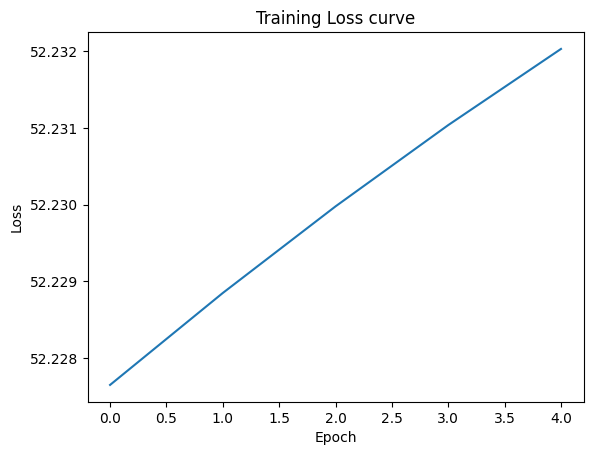

In [ ]:
#@title plot loss graph
import matplotlib.pyplot as plt
losses = []
for epoch in range(num_epochs):
  images = images.to(device)
  labels = labels.to(device)

  outputs = model(images)
  loss = criterion(outputs, labels)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  running_loss += loss.item()
  losses.append(running_loss)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss curve')
plt.show()

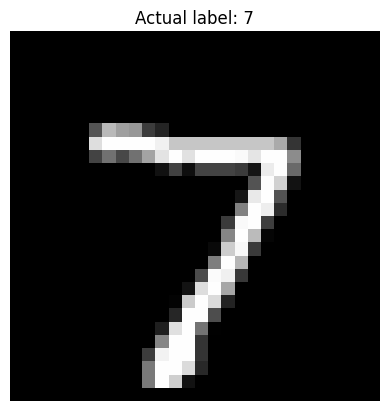

Predicted label: 7


In [ ]:
#@title Predict Custom Image
model.eval()
images, label = test_datasets[0]
plt.imshow(images.squeeze(), cmap = 'gray')
plt.title(f"Actual label: {label}")
plt.axis('off')
plt.show()

#Predict using model
image = images.unsqueeze(0).to(device)
outputs = model(image)
_, predicted = torch.max(outputs.data, 1)
print(f"Predicted label: {predicted.item()}")

Saving 8 img 1.png to 8 img 1.png
8 img 1.png


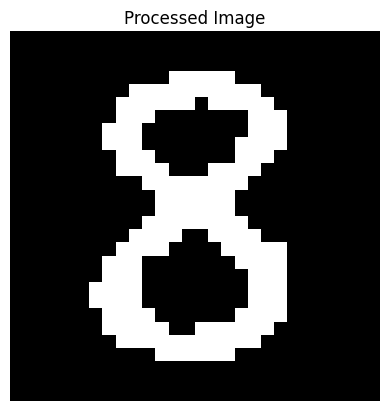

Predicted Digit: 4


In [ ]:
from google.colab import files
uploaded = files.upload()

from PIL import Image
import cv2

# Get uploaded file name
img_path = list(uploaded.keys())[0]
print(img_path)

# Open image
image = Image.open(img_path).convert('L')  # convert to grayscale

# Define transformations

image = np.array(image)
image = cv2.resize(image, (28, 28))
_, image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)
image = 255-image

import matplotlib.pyplot as plt

plt.imshow(image, cmap='gray')
plt.title("Processed Image")
plt.axis('off')
plt.show()

image = Image.fromarray(image)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Apply transform
image = transform(image)

image = image.unsqueeze(0).to(device)

outputs = model(image)
_, predicted = torch.max(outputs, 1)

print(f"Predicted Digit: {predicted.item()}")

In [ ]:
!pip install gradio

In [ ]:
#@title creating Web page

import torch
import gradio as gr

def predict_digit(image):
    import numpy as np
    from PIL import Image

    model.eval()

    # 🔥 Handle Gradio Sketchpad output
    if isinstance(image, dict):
        image = image["composite"]   # get actual drawing

    # Convert to PIL
    image = Image.fromarray(image).convert('L')

    # Convert to numpy for inversion
    image = np.array(image)

    # Invert colors (IMPORTANT)
    image = 255 - image

    # Back to PIL
    image = Image.fromarray(image)

    transform = transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    image = transform(image)
    image = image.unsqueeze(0).to(device)

    outputs = model(image)
    _, predicted = torch.max(outputs, 1)

    return f"Predicted Digit: {predicted.item()}"
    image = image["composite"]
    return predict_digit(image)

    import torch.nn.functional as F

    probs = F.softmax(outputs, dim=1)
    confidence = probs[0][predicted].item()

    return f"Digit: {predicted.item()} (Confidence: {confidence:.2f})"

interface = gr.Interface(
    fn=predict_digit,
    inputs=gr.Sketchpad(),   # Draw digit here
    outputs="text",
    title="🧠 AI Digit Recognizer",
    description="Draw a digit (0–9) and the AI will predict it!"
)

# Launch app
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e4c87677d1259be368.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
